RMSE: 2.2305214949509264
MAE: 1.7967080810572915
R2 Score: 0.7385889885470567


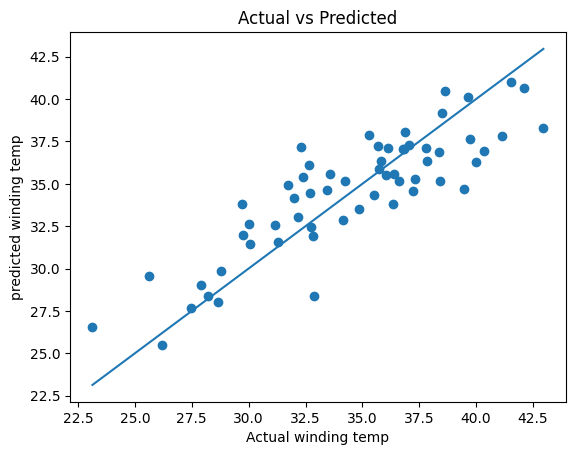

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LinearRegression
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
n = 300

hours_op = np.random.uniform(0, 10, n)
ambient = np.random.uniform(20, 40, n)
load_pct = np.random.uniform(0.2, 0.1, n)
voltage = np.random.uniform(210, 240, n)


X = np.column_stack((hours_op, ambient, load_pct, voltage))

noise = np.random.normal(0, 2, n)

y= (
    0.8 * hours_op +
    0.5 * ambient +
    25 * load_pct +
    0.05 * voltage +
    noise
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

plt.figure()
plt.scatter(y_test, y_pred)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual winding temp")
plt.ylabel("predicted winding temp")
plt.title("Actual vs Predicted")

plt.show()